In [2]:
##### سلول اول
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/content/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/content'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/content/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/content/test_FD001.txt
/content/RUL_FD001.txt
/content/train_FD001.txt
/content/.config/gce
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/default_configs.db
/content/.config/config_sentinel
/content/.config/.last_survey_prompt.yaml
/content/.config/.last_update_check.json
/content/.config/active_config
/content/.config/.last_opt_in_prompt.yaml
/content/.config/logs/2026.08.10/13.31.30.727990.log
/content/.config/logs/2026.08.10/13.31.01.432717.log
/content/.config/logs/2026.08.10/13.30.49.573652.log
/content/.config/logs/2026.08.10/13.31.19.598417.log
/content/.config/logs/2026.08.10/13.30.22.650150.log
/content/.config/logs/2026.08.10/13.31.29.952213.log
/content/.config/configurations/config_default
/content/sample_data/README.md
/content/sample_data/anscombe.json
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_test.csv
/content/sample_data/california_housing_te

In [3]:
###سلول دوم
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn import linear_model
from sklearn.model_selection import GridSearchCV
from scipy import interpolate

min_max_scaler = preprocessing.MinMaxScaler()

# RUL_01 = np.loadtxt('./c-mapss-data/RUL_FD001.txt')
# train_01_raw = np.loadtxt('.c-mapss-data/train_FD001.txt')
# test_01_raw = np.loadtxt('./c-mapss-data/test_FD001.txt')

RUL_01 = np.loadtxt('/content/RUL_FD001.txt')
train_01_raw = np.loadtxt('/content/train_FD001.txt')
test_01_raw = np.loadtxt('/content/test_FD001.txt')

train_01_raw[:,2:] = min_max_scaler.fit_transform(train_01_raw[:,2:])
test_01_raw[:,2:] = min_max_scaler.transform(test_01_raw[:,2:])

train_01_nor = train_01_raw
test_01_nor = test_01_raw

#FD001变量选择
train_01_nor = np.delete(train_01_nor, [2,3,4, 5,9,10,14,20,22,23], axis=1) # select sensor
test_01_nor = np.delete(test_01_nor, [2,3,4,5,9,10,14,20,22,23], axis=1)  #

# train_01_nor = np.delete(train_01_nor, [2,3,4,5,9,10,14,20,22,23], axis=1) # select sensor
# test_01_nor = np.delete(test_01_nor, [2,3,4,5,9,10,14,20,22,23], axis=1)  #

max_RUL = 125.0 #max RUL for training
winSize = 25
trainX = []
trainY = []
testX = []
testY = []

regr = linear_model.LinearRegression() # feature of linear coefficient

def fea_extract(data): # feature extraction of two features
    fea = []
    #print(data.shape)
    x = np.array(range(data.shape[0])) #数据的长度
    for i in range(data.shape[1]):#数据特征的数量
        fea.append(np.mean(data[:,i]))
        regr.fit(x.reshape(-1,1),np.ravel(data[:,i])) #ravel将多维数组变成一维数组
        fea = fea+list(regr.coef_)
        #print(regr.coef_)
    return fea

testInd = []
testLen = []

for i in range(1,int(np.max(train_01_nor[:,0]))+1):
    ind =np.where(train_01_nor[:,0]==i)
    ind = ind[0]
    data_temp = train_01_nor[ind,:]
    for j in range(len(data_temp)-winSize+1): #时间序列步长
        trainX.append(data_temp[j:j+winSize,2:].tolist())
        train_RUL = len(data_temp)-winSize-j #每行数据对应的剩余寿命
        if train_RUL > max_RUL:
            train_RUL = max_RUL  #对剩余寿命进行修正
        trainY.append(train_RUL)

for i in range(1,int(np.max(test_01_nor[:,0]))+1):

    ind =np.where(test_01_nor[:,0]==i)
    ind = ind[0]
    testLen.append(len(ind))
    data_temp = test_01_nor[ind,:]

    if len(data_temp)<winSize:
        data_temp_a = []
        for myi in range(data_temp.shape[1]):
            x1 = np.linspace(0, winSize-1, len(data_temp) )
            x_new = np.linspace(0, winSize-1, winSize)
            tck = interpolate.splrep(x1, data_temp[:,myi])
            a = interpolate.splev(x_new, tck)
            data_temp_a.append(a.tolist())
        data_temp_a = np.array(data_temp_a)
        data_temp = data_temp_a.T
        data_temp = data_temp[:,2:]
    else:
        data_temp = data_temp[-winSize:,2:]

    data_temp = np.reshape(data_temp,(1,data_temp.shape[0],data_temp.shape[1]))
    if i == 1:
        testX = data_temp
    else:
        testX = np.concatenate((testX,data_temp),axis = 0)
    if RUL_01[i-1] > max_RUL:
        testY.append(max_RUL)
    else:
        testY.append(RUL_01[i-1])

trainX = np.array(trainX)
testX = np.array(testX)

trainY = np.array(trainY)/max_RUL # normalize to 0-1 for training

trainData = trainX
testData = testX
trainTarget = trainY
testTarget = testY


print("X_trainData的形状", trainData.shape)
print("X_testData的形状", testData.shape)

X_trainData的形状 (18231, 25, 14)
X_testData的形状 (100, 25, 14)


In [4]:
###سلول سوم
from keras.layers import Input, Dense, LSTM ,Conv1D,Dropout,Bidirectional,Multiply
from keras.models import Model
import keras.backend as K
#from attention_utils import get_activations
from keras.layers import Multiply
from keras.layers import *
from keras.models import *

import  pandas as pd
import  numpy as np


In [5]:
##سلول چهارم اصلاحی
import time
import random
import numpy as np
import tensorflow as tf

from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.optimizers import Adam

rmse_test_list = []
score_test_list = []
c_max2_list = []

N = 10

seeds = [11, 22, 33, 44, 55, 66, 77, 88, 99, 110]

for j in range(1, N + 1):

    print(
        "\n********************** Test No ",
        j,
        "/",
        N,
        ":**********************"
    )

    t = time.process_time()

    # بذر اجرای جاری
    seed = seeds[j - 1]

    # پاک‌کردن مدل قبلی از حافظه
    K.clear_session()

    # تنظیم بذرها پیش از ساخت مدل
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

    print("Seed:", seed)

    def attention_model():

        inputs = Input(
            shape=(TIME_STEPS, INPUT_DIMS)
        )

        x = Conv1D(
            filters=64,
            kernel_size=3,
            activation="relu",
            padding="same"
        )(inputs)

        x = Dropout(drop)(x)

        lstm_out = Bidirectional(
            LSTM(
                units=64,
                return_sequences=True
            )
        )(x)

        lstm_out = Dropout(drop)(lstm_out)
        lstm_out = Flatten()(lstm_out)

        output = Dense(
            1,
            activation="linear"
        )(lstm_out)

        optimizer = Adam(
            learning_rate=0.001
        )

        model = Model(
            inputs=[inputs],
            outputs=output
        )

        model.compile(
            optimizer=optimizer,
            loss="mse"
        )

        return model

    INPUT_DIMS = 14
    TIME_STEPS = 25
    lstm_units = 64

    # این مقدار را در هر مرحله دستی تغییر بده
    drop = 0.3

    # ساخت مدل پس از تنظیم بذر
    m = attention_model()
    m.summary()

    batch_size = 256
    nb_epoch = 64

    history = m.fit(
        trainData,
        trainTarget,
        batch_size=batch_size,
        epochs=nb_epoch,
        shuffle=True
    )
    def myScore(y_ture, y_pred):
        score = 0
        for i in range(len(y_pred)):
            if y_ture[i] <= y_pred[i]:
                score = score + np.exp(-(y_ture[i] - y_pred[i]) / 10.0) - 1
            else:
                score = score + np.exp((y_ture[i] - y_pred[i]) / 13.0) - 1
        return score


    yPreds = m.predict(testData)
    yPreds = yPreds * max_RUL
    # yPreds = yPreds[:, 1]
    print(yPreds.shape)
    c_max2 = yPreds
#     c_max2.to_csv(r'/content/CNN-Bi-LSTM-AM-Preds_FD001-.csv', index=False)
    test_rmse = np.sqrt(mean_squared_error(testTarget, yPreds))
    test_score = myScore(testTarget, yPreds)
    print('lastScore:', test_score, 'lastRMSE', test_rmse)
    rmse_test_list.append(test_rmse)
    score_test_list.append(test_score)
    c_max2_list.append(c_max2)

    print("++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
    print("time: " , (time.process_time()-t),"sec")
    print('')


# c_max2 = pd.DataFrame(yPreds)
print('All RMSE: ',rmse_test_list)
print('\nAll MAE: ',score_test_list)
print('\n******************************************************************************************')
print('***************** mean RMSE', np.mean(rmse_test_list),"***************")
print('***************** min RMSE', np.min(rmse_test_list), "***************")
print('******************************************************************************************')
print('***************** mean SCORE : ',np.mean(score_test_list),"*************")
print('***************** min SCORE : ',np.min(score_test_list), "*************")

print('******************************************************************************************\n')
print("\n++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("Total time: " , (time.process_time()-t),"sec")
# print(c_max2_list)




********************** Test No  1 / 10 :**********************
Seed: 11


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 25, 14)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 25, 64)         │         2,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 25, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         3,201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,001 (281.25 KB)

 Trainable params: 72,001 (281.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 25, 14)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 25, 64)         │         2,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 25, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         3,201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,001 (281.25 KB)

 Trainable params: 72,001 (281.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0621
Epoch 2/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0291
Epoch 3/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0251
Epoch 4/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0231
Epoch 5/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0214
Epoch 6/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0200
Epoch 7/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0189
Epoch 8/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0184
Epoch 9/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0175
Epoch 10/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0171
Epoch 11/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0165
Epoch 12/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0162
Epoch 13/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0160
Epoch 14/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0158
Epoch 15/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0156
Epoch 

In [6]:
###برای ذخیره سازی اطلاعات حاصل از هر مقدار پی
import pandas as pd
import numpy as np

# مقدار Dropout مربوط به اجرای فعلی
current_drop = 0.3
drop_name = str(current_drop).replace(".", "_")

# ذخیره نتایج هر ۱۰ اجرا
raw_results = pd.DataFrame({
    "run": range(1, len(rmse_test_list) + 1),
    "rmse": rmse_test_list,
    "score": score_test_list
})

raw_filename = f"FD001_dropout_{drop_name}_raw.csv"
raw_results.to_csv(raw_filename, index=False)

# محاسبه و ذخیره خلاصه نتایج
summary = pd.DataFrame([{
    "dropout": current_drop,
    "number_of_runs": len(rmse_test_list),
    "mean_rmse": np.mean(rmse_test_list),
    "std_rmse": np.std(rmse_test_list, ddof=1),
    "min_rmse": np.min(rmse_test_list),
    "mean_score": np.mean(score_test_list),
    "std_score": np.std(score_test_list, ddof=1),
    "min_score": np.min(score_test_list)
}])

summary_filename = f"FD001_dropout_{drop_name}_summary.csv"
summary.to_csv(summary_filename, index=False)

print("فایل‌ها ذخیره شدند:")
print(raw_filename)
print(summary_filename)

display(raw_results)
display(summary)

فایل‌ها ذخیره شدند:
FD001_dropout_0_3_raw.csv
FD001_dropout_0_3_summary.csv


,run,rmse,score
0,1,13.916337,[311.3570256698522]
1,2,13.453638,[327.546280740493]
2,3,12.693775,[235.0409782928569]
3,4,13.553332,[309.90395133144574]
4,5,13.126956,[234.87480147187878]
5,6,13.433814,[326.8889239965696]
6,7,12.819590,[222.98037664466]
7,8,13.006109,[246.42763942439632]
8,9,13.856049,[331.1667378571194]
9,10,12.963046,[284.0160490486407]


,dropout,number_of_runs,mean_rmse,std_rmse,min_rmse,mean_score,std_score,min_score
0,0.3,10,13.282264,0.424233,12.693775,283.020276,43.862931,222.980377


In [7]:
## برای دانلود فایل خای ایجاد شده
from google.colab import files

files.download(raw_filename)
files.download(summary_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
my_array = np.array(c_max2_list)
# c_max2_list.toarray
matrix_2d = my_array.reshape(my_array.shape[0], -1)
# c_max1.to_csv(r'/content/ARCCCCCCCCCCCCCCCCC--.csv', index=False)
# c_max2_list.to_csv(r'/content/ASCCCCCCCCCCCCCCCC.csv', index=False)
matrix_2d.shape
c_max3 = pd.DataFrame(matrix_2d)
c_max3.to_csv(r'/content/RUL-FD001.csv', index=False)

c_max1 = pd.DataFrame(rmse_test_list)
c_max2 = pd.DataFrame(score_test_list)
# c_max3 = pd.DataFrame(c_max2_list)

c_max1.to_csv(r'/content/RMSE-FD001.csv', index=False)
c_max2.to_csv(r'/content/SCORE-FD001.csv', index=False)

Mean RMSE of 10 runs: 13.282264464299052
Representative run: 6
Representative seed: 66
Representative RMSE: 13.43381353865708


,engine_id,actual_rul,predicted_rul,representative_run,seed
0,1,112.0,124.268364,6,66
1,2,98.0,129.452393,6,66
2,3,69.0,54.089436,6,66
3,4,82.0,78.468239,6,66
4,5,91.0,94.763672,6,66
5,6,93.0,90.956345,6,66
6,7,91.0,114.897232,6,66
7,8,95.0,86.263199,6,66
8,9,111.0,121.039352,6,66
9,10,96.0,100.348465,6,66


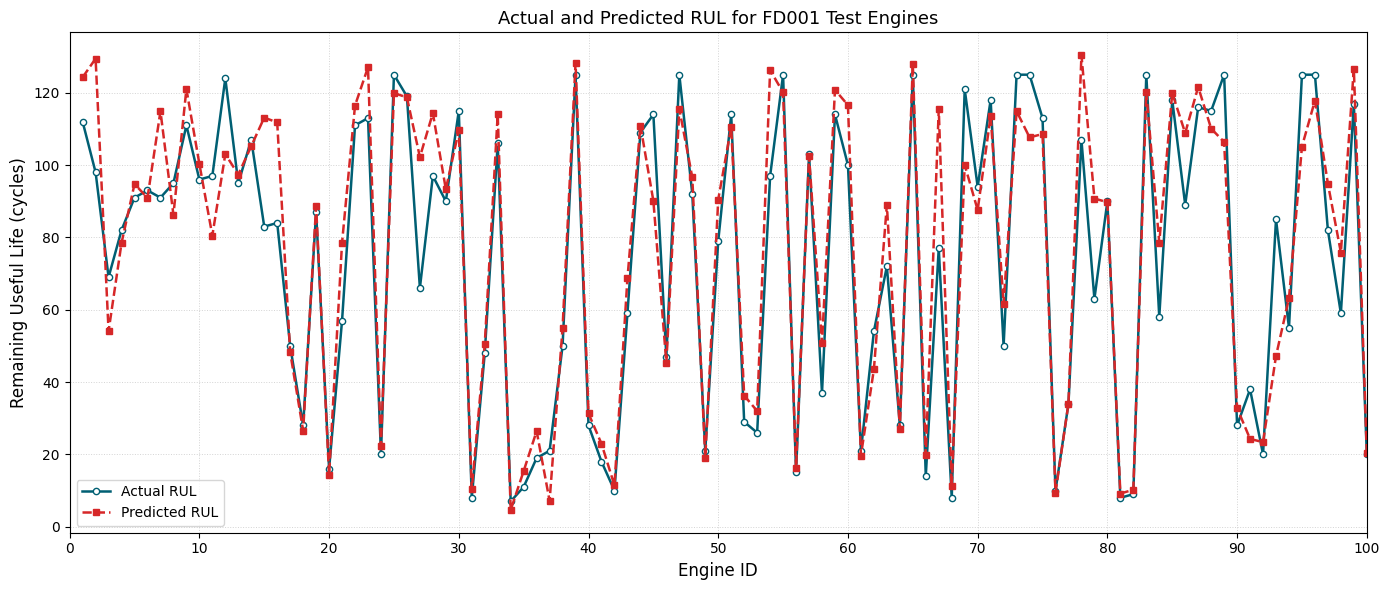


فایل خروجی آماده دانلود است:
/content/FD001_actual_vs_predicted_output.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
# سلول جدید: نمودار RUL واقعی و پیش‌بینی‌شده
# مدل منتخب: Dropout = 0.3
# این کد از میانگین پیش‌بینی‌های 10 اجرا استفاده نمی‌کند.
# یک اجرای نماینده انتخاب می‌شود که RMSE آن به میانگین RMSE ده اجرا نزدیک‌تر است.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import zipfile


# ---------------------------------------------------------
# 1) آماده‌سازی خروجی 10 اجرای مدل
# ---------------------------------------------------------

all_predictions = np.asarray(c_max2_list, dtype=float)
all_predictions = np.squeeze(all_predictions)

# اگر فقط یک اجرا وجود داشته باشد
if all_predictions.ndim == 1:
    all_predictions = all_predictions.reshape(1, -1)

actual_rul = np.asarray(testTarget, dtype=float).reshape(-1)
rmse_values = np.asarray(rmse_test_list, dtype=float).reshape(-1)

if all_predictions.shape[0] != len(rmse_values):
    raise ValueError(
        "تعداد مجموعه‌های پیش‌بینی با تعداد مقادیر RMSE برابر نیست. "
        f"Predictions: {all_predictions.shape[0]}, "
        f"RMSE values: {len(rmse_values)}"
    )

if all_predictions.shape[1] != len(actual_rul):
    raise ValueError(
        "تعداد پیش‌بینی‌ها با تعداد مقادیر واقعی RUL برابر نیست. "
        f"Predictions shape: {all_predictions.shape}, "
        f"Actual RUL shape: {actual_rul.shape}"
    )


# ---------------------------------------------------------
# 2) انتخاب اجرای نماینده، نه بهترین اجرا و نه میانگین پیش‌بینی‌ها
# ---------------------------------------------------------

mean_rmse = np.mean(rmse_values)

representative_index = int(
    np.argmin(np.abs(rmse_values - mean_rmse))
)

representative_run = representative_index + 1
representative_seed = seeds[representative_index]
representative_rmse = rmse_values[representative_index]

# پیش‌بینی یک اجرای واقعی مدل
predicted_rul = all_predictions[representative_index].reshape(-1)

engine_ids = np.arange(1, len(actual_rul) + 1)

print("Mean RMSE of 10 runs:", mean_rmse)
print("Representative run:", representative_run)
print("Representative seed:", representative_seed)
print("Representative RMSE:", representative_rmse)


# ---------------------------------------------------------
# 3) ذخیره مقادیر اجرای نماینده
# ---------------------------------------------------------

predictions_df = pd.DataFrame({
    "engine_id": engine_ids,
    "actual_rul": actual_rul,
    "predicted_rul": predicted_rul,
    "representative_run": representative_run,
    "seed": representative_seed
})

csv_filename = "/content/FD001_representative_run_predictions.csv"
predictions_df.to_csv(csv_filename, index=False)

display(predictions_df.head(10))


# ---------------------------------------------------------
# 4) نمودار RUL واقعی در برابر RUL پیش‌بینی‌شده
# ---------------------------------------------------------

plt.figure(figsize=(14, 6))

# منحنی واقعی: آبی نفتی، پیوسته و دایره‌ای
plt.plot(
    engine_ids,
    actual_rul,
    color="#005F73",
    linestyle="-",
    linewidth=1.8,
    marker="o",
    markersize=4.5,
    markerfacecolor="white",
    markeredgecolor="#005F73",
    markeredgewidth=1.0,
    label="Actual RUL"
)

# منحنی پیش‌بینی: قرمز، خط‌چین و مربعی
plt.plot(
    engine_ids,
    predicted_rul,
    color="#D62728",
    linestyle="--",
    linewidth=1.8,
    marker="s",
    markersize=4.2,
    markerfacecolor="#D62728",
    markeredgecolor="#D62728",
    label="Predicted RUL"
)

plt.xlabel("Engine ID", fontsize=12)
plt.ylabel("Remaining Useful Life (cycles)", fontsize=12)
plt.title(
    "Actual and Predicted RUL for FD001 Test Engines",
    fontsize=13
)

plt.xlim(1, len(actual_rul))
plt.xticks(np.arange(0, len(actual_rul) + 1, 10))
plt.grid(True, linestyle=":", linewidth=0.7, alpha=0.55)
plt.legend(frameon=True, fontsize=10)
plt.tight_layout()

rul_figure = "/content/FD001_actual_vs_predicted_RUL.png"

plt.savefig(
    rul_figure,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


# ---------------------------------------------------------
# 5) دانلود یکجای نمودار و داده‌ها
# ---------------------------------------------------------

output_files = [
    rul_figure,
    csv_filename
]

zip_filename = "/content/FD001_actual_vs_predicted_output.zip"

with zipfile.ZipFile(zip_filename, "w") as zip_file:
    for file_path in output_files:
        zip_file.write(
            file_path,
            arcname=file_path.split("/")[-1]
        )

print("\nفایل خروجی آماده دانلود است:")
print(zip_filename)

files.download(zip_filename)
